# LeetCode #11: Container With Most Water



https://leetcode.com/problems/container-with-most-water/



## Comparison of Approaches



| Approach | Time Complexity | Space Complexity |

| :--- | :--- | :--- |

| **Brute Force** | $O(n^2)$ | $O(1)$ |

| **Optimal: Two Pointers** ★ | $O(n)$ | $O(1)$ |



---



## Understanding the Methods



### Brute Force

Check every pair of lines $(i, j)$ and compute $\min(h[i], h[j]) \times (j - i)$. All $\binom{n}{2}$ pairs are evaluated, making this $O(n^2)$ — unusable for large inputs.



### Optimal: Two Pointers ★

Start with pointers at both ends (maximum possible width). At each step, compute the area and move the pointer pointing to the **shorter** line inward. Moving the taller line can only decrease width while the height is still bounded by the shorter — so it can never improve the answer. Moving the shorter line is the only way to possibly find a taller line that compensates.



**Why this is better than Brute Force:** $O(n)$ vs $O(n^2)$ time, same $O(1)$ space. The greedy proof guarantees we never skip the optimal pair.



**Constraints:**

* `n == height.length`

* `2 <= n <= 10^5`

* `0 <= height[i] <= 10^4`

## Solutions



### C#

In [ ]:
public class Solution {

    public int MaxArea(int[] height) {

        int left = 0, right = height.Length - 1, maxWater = 0;

        while (left < right) {

            // Area is limited by the shorter wall

            int water = Math.Min(height[left], height[right]) * (right - left);

            maxWater = Math.Max(maxWater, water);

            // Moving the taller pointer can only reduce area; advance the shorter one

            if (height[left] < height[right]) left++;

            else right--;

        }

        return maxWater;

    }

}

### Python

In [ ]:
class Solution:

    def maxArea(self, height: list[int]) -> int:

        left, right = 0, len(height) - 1

        max_water = 0

        while left < right:

            # Area is limited by the shorter wall

            water = min(height[left], height[right]) * (right - left)

            max_water = max(max_water, water)

            # Moving the taller pointer can only reduce area; advance the shorter one

            if height[left] < height[right]:

                left += 1

            else:

                right -= 1

        return max_water

### Go

In [ ]:
func maxArea(height []int) int {

    left, right := 0, len(height)-1

    maxWater := 0

    for left < right {

        // Area is limited by the shorter wall

        h := height[left]

        if height[right] < h {

            h = height[right]

        }

        water := h * (right - left)

        if water > maxWater {

            maxWater = water

        }

        // Moving the taller pointer can only reduce area; advance the shorter one

        if height[left] < height[right] {

            left++

        } else {

            right--

        }

    }

    return maxWater

}

### Rust

In [ ]:
impl Solution {

    pub fn max_area(height: Vec<i32>) -> i32 {

        let mut left = 0;

        let mut right = height.len() - 1;

        let mut max_water = 0;

        while left < right {

            // Area is limited by the shorter wall

            let water = height[left].min(height[right]) * (right - left) as i32;

            max_water = max_water.max(water);

            // Moving the taller pointer can only reduce area; advance the shorter one

            if height[left] < height[right] {

                left += 1;

            } else {

                right -= 1;

            }

        }

        max_water

    }

}

## Example Scenarios

**Example 1 — Common Case**\
**Input:** `height = [1,8,6,2,5,4,8,3,7]`\
Left starts at index 0 (h=1), right at index 8 (h=7). Left advances since 1 < 7. After several moves, the best container is between index 1 (h=8) and index 8 (h=7): $\min(8,7) \times 7 = 49$ → **49**.

**Example 2 — Slightly Complex**\
**Input:** `height = [4,3,2,1,4]`\
Left (h=4) and right (h=4) are equal, so right moves inward. No inner pair beats the endpoints: $\min(4,4) \times 4 = 16$ → **16**.

**Example 3 — Edge Case: Time Factor**\
**Input:** `height = [10,9,8,7,6,5,4,3,2,1]`\
Strictly descending array: right pointer steps inward all $n-1 = 9$ times before meeting left, touching every element — maximum iterations for this array size. Best area is $\min(10,5) \times 5 = 25$ at indices 0 and 5 → **25**.

**Example 4 — Edge Case: Space Factor**\
**Input:** `height = [3,3]`\
Minimum-size input ($n = 2$): one iteration, one area check. Proves $O(1)$ space — only three integers (`left`, `right`, `maxWater`) are maintained regardless of input size → **3**.

**Example 5 — Almost-Impossible but Plausible**\
**Input:** `height = [1,100,1,1,1,1,1,100,1]`\
The wide shallow container at the endpoints ($\min(1,1) \times 8 = 8$) is dwarfed by the tall narrow container at indices 1 and 7 ($\min(100,100) \times 6 = 600$). Both endpoints are short (h=1), so left and right advance inward immediately and find the tall pair on iteration 3 → **600**.

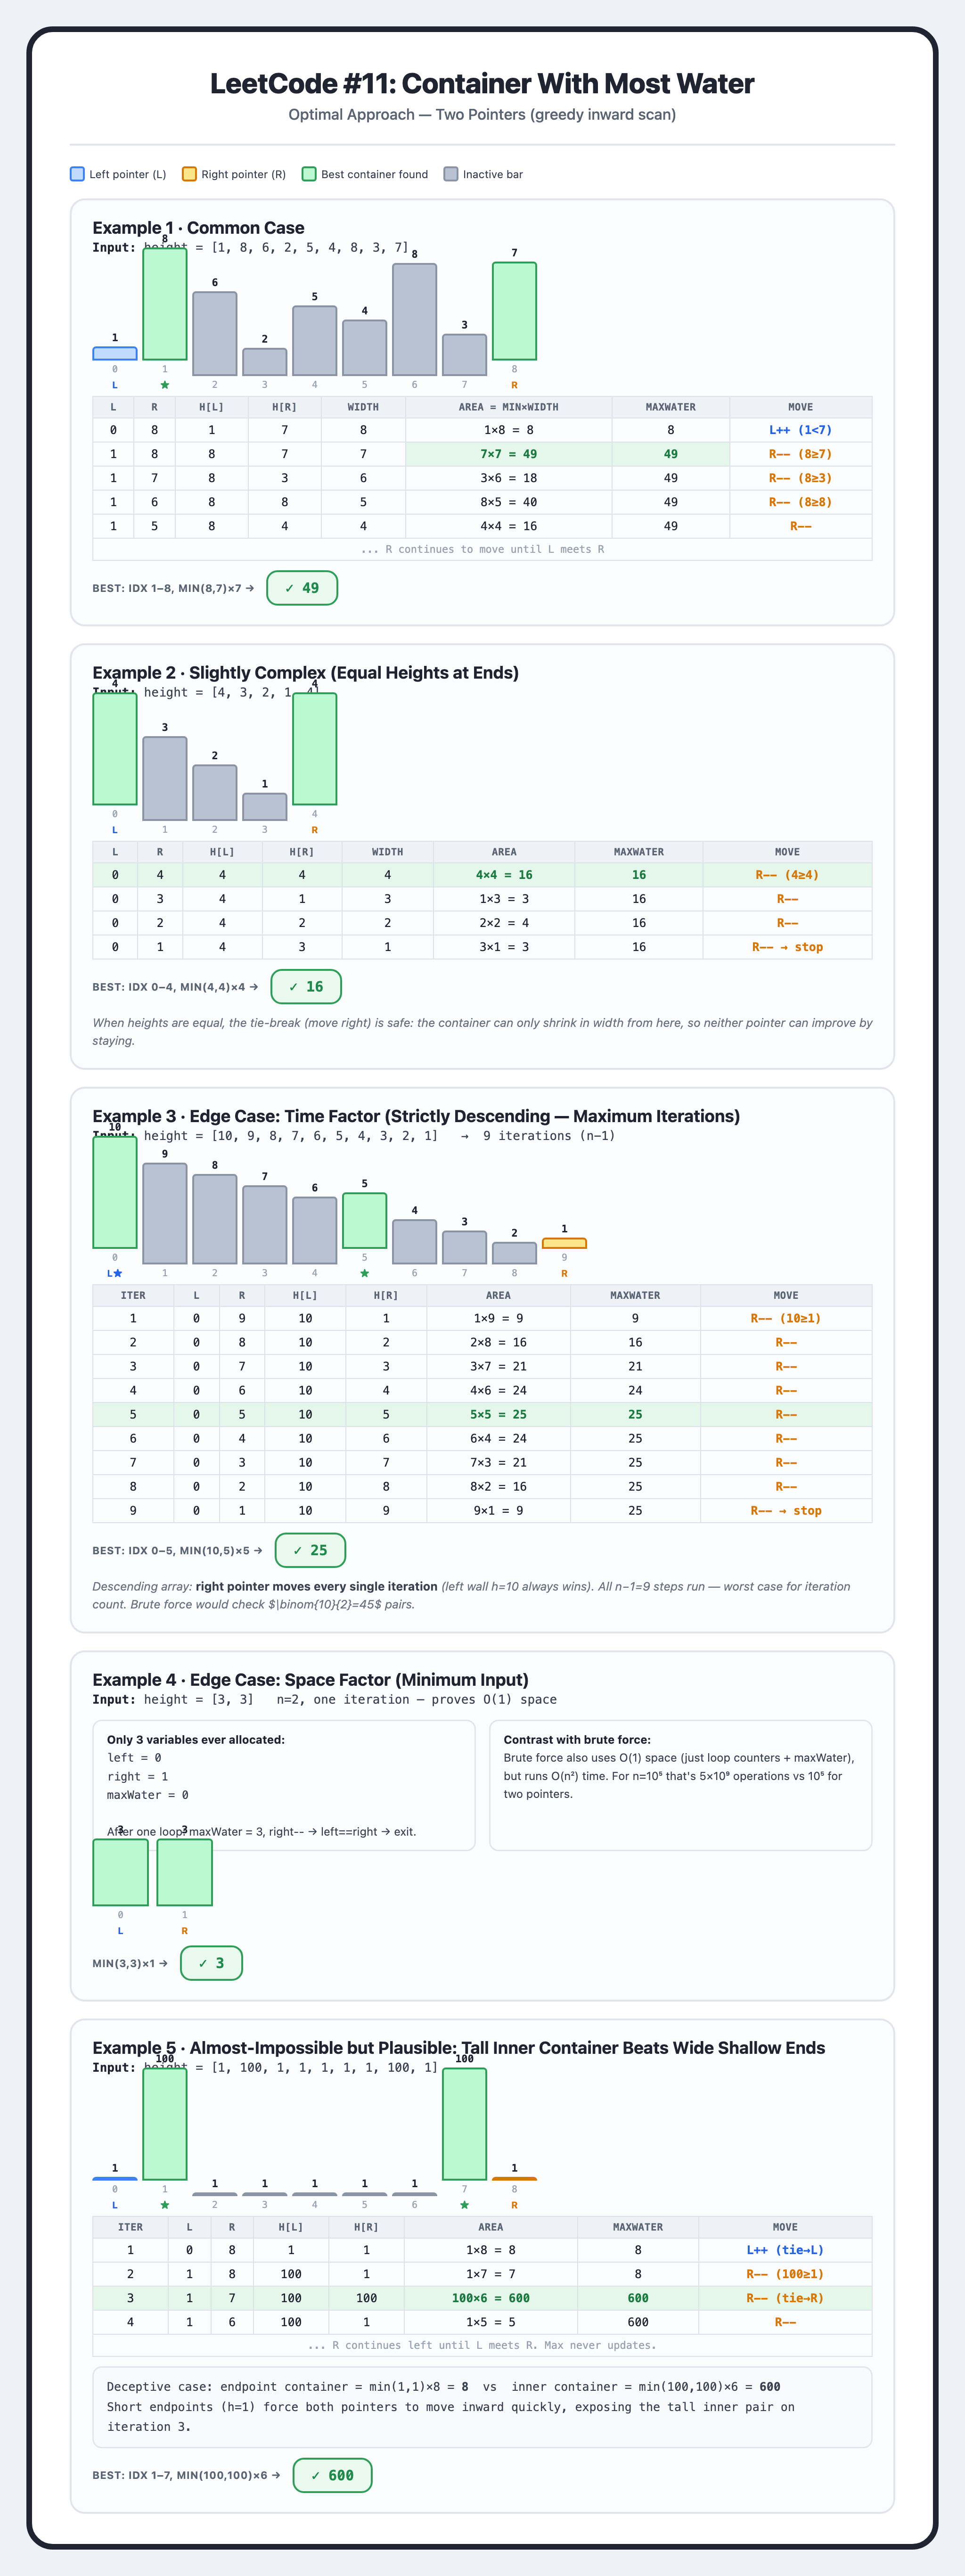